# JA4 + JA4S + JA4T + JA4TS Full Fingerprints (Dictionary Classifier)


## Data Loading

This section selects the fingerprint columns used in this experiment, locates the updated `raw_features.csv` file, loads it, and removes rows where any required fingerprint is empty.


In [1]:
import pandas as pd
from pathlib import Path

# Select the fingerprint columns used by this dictionary experiment.
signature_columns = [
    "ja4",
    "ja4s",
    "ja4t",
    "ja4ts"
]
# Keep the device label together with the selected fingerprints.
selected_columns = ["device_name", *signature_columns]

csv_path = Path("D:/TFG_GemmaBeatrizVate/1_Data/raw_fingerprints/raw_features.csv")

# Remove empty or placeholder fingerprint values before modeling.
def is_valid_fingerprint(series: pd.Series) -> pd.Series:
    cleaned = series.fillna("").astype(str).str.strip().str.lower()
    return cleaned.ne("") & cleaned.ne("(empty)") & cleaned.ne("(emtpy)")

# Load the raw feature table and keep only rows where all required fingerprints are present.
df = pd.read_csv(csv_path, dtype=str, low_memory=False)
df = df[
    is_valid_fingerprint(df["ja4"])
    & is_valid_fingerprint(df["ja4s"])
    & is_valid_fingerprint(df["ja4t"])
    & is_valid_fingerprint(df["ja4ts"])
].copy()
df = df[selected_columns].copy()

print(f"Dataset used: {csv_path}")
print(f"Complete fingerprints analyzed: {signature_columns}")
print(f"Rows after filtering empty fingerprints: {len(df)}")
df.head()

Dataset used: D:\TFG_GemmaBeatrizVate\1_Data\raw_fingerprints\raw_features.csv
Complete fingerprints analyzed: ['ja4', 'ja4s', 'ja4t', 'ja4ts']
Rows after filtering empty fingerprints: 401


,device_name,ja4,ja4s,ja4t,ja4ts
394,Rbcior_Camera,t12d040600_39def8a70f78_9b994c9d23f8,t120300_c027_7815a3cc5eb2,14600_2-4-8-1-3_1460_3,65535_2-4-8-1-3_1460_9
586,Rbcior_Camera,t12d040600_39def8a70f78_9b994c9d23f8,t120400_c013_d23d0754cf28,14600_2-4-8-1-3_1460_3,14600_2-3-1-4-1-1_1432_8
686,Yutron_Plug_1_Power_Outlet,t12i020600_96495e174321_c9df22c671e6,t120300_00ae_468c819633e6,2920_2_1460_0,65535_2_1460_0
736,Rbcior_Camera,t12d040600_39def8a70f78_9b994c9d23f8,t120400_c013_d23d0754cf28,14600_2-4-8-1-3_1460_3,14600_2-3-1-4-1-1_1432_8
976,Rbcior_Camera,t12d040600_39def8a70f78_9b994c9d23f8,t120400_c013_d23d0754cf28,14600_2-4-8-1-3_1460_3,14600_2-3-1-4-1-1_1432_8


## Dataset Summary

This section builds a complete fingerprint bundle for each record and compares the number of samples with the number of distinct fingerprint bundles available for each device.


Number of samples per device_name
device_name
Rbcior_Camera                     144
Arlo_Q_Indoor_Camera               56
HeimVision_Smart_WiFi_Camera       38
Amazon_Echo_Show_Audio             18
Lumiman_Bulb_Lighting              13
Yi_Indoor_Camera                   12
Yutron_Plug_1_Power_Outlet         11
Teckin_Plug_2_Power_Outlet         10
Harman_Kardon_Audio                 9
Yi_Outdoor_Camera                   9
Teckin_Plug_1_Power_Outlet          8
Teckin_Light_Strip_Lighting         8
Atomi_Coffee_Maker                  8
UNKNOWN                             8
SmartThings_Hub                     7
Amazon_Alexa_Echo_Dot_1_Audio       6
Amazon_Alexa_Echo_Dot_2_Audio       6
Amazon_Alexa_Echo_Studio_Audio      5
Yutron_Plug_2_Power_Outlet          4
AeoTec_Smart_Home_Hub               3
Fibaro_Home_Center_Lite_Hub         2
LampUX_RGB_Lighting                 2
Netatmo_Camera                      2
GoSund_Smart_Plug_WP2_1             2
HeimVision_Radio_Lamp_Lighting      2
Gosu

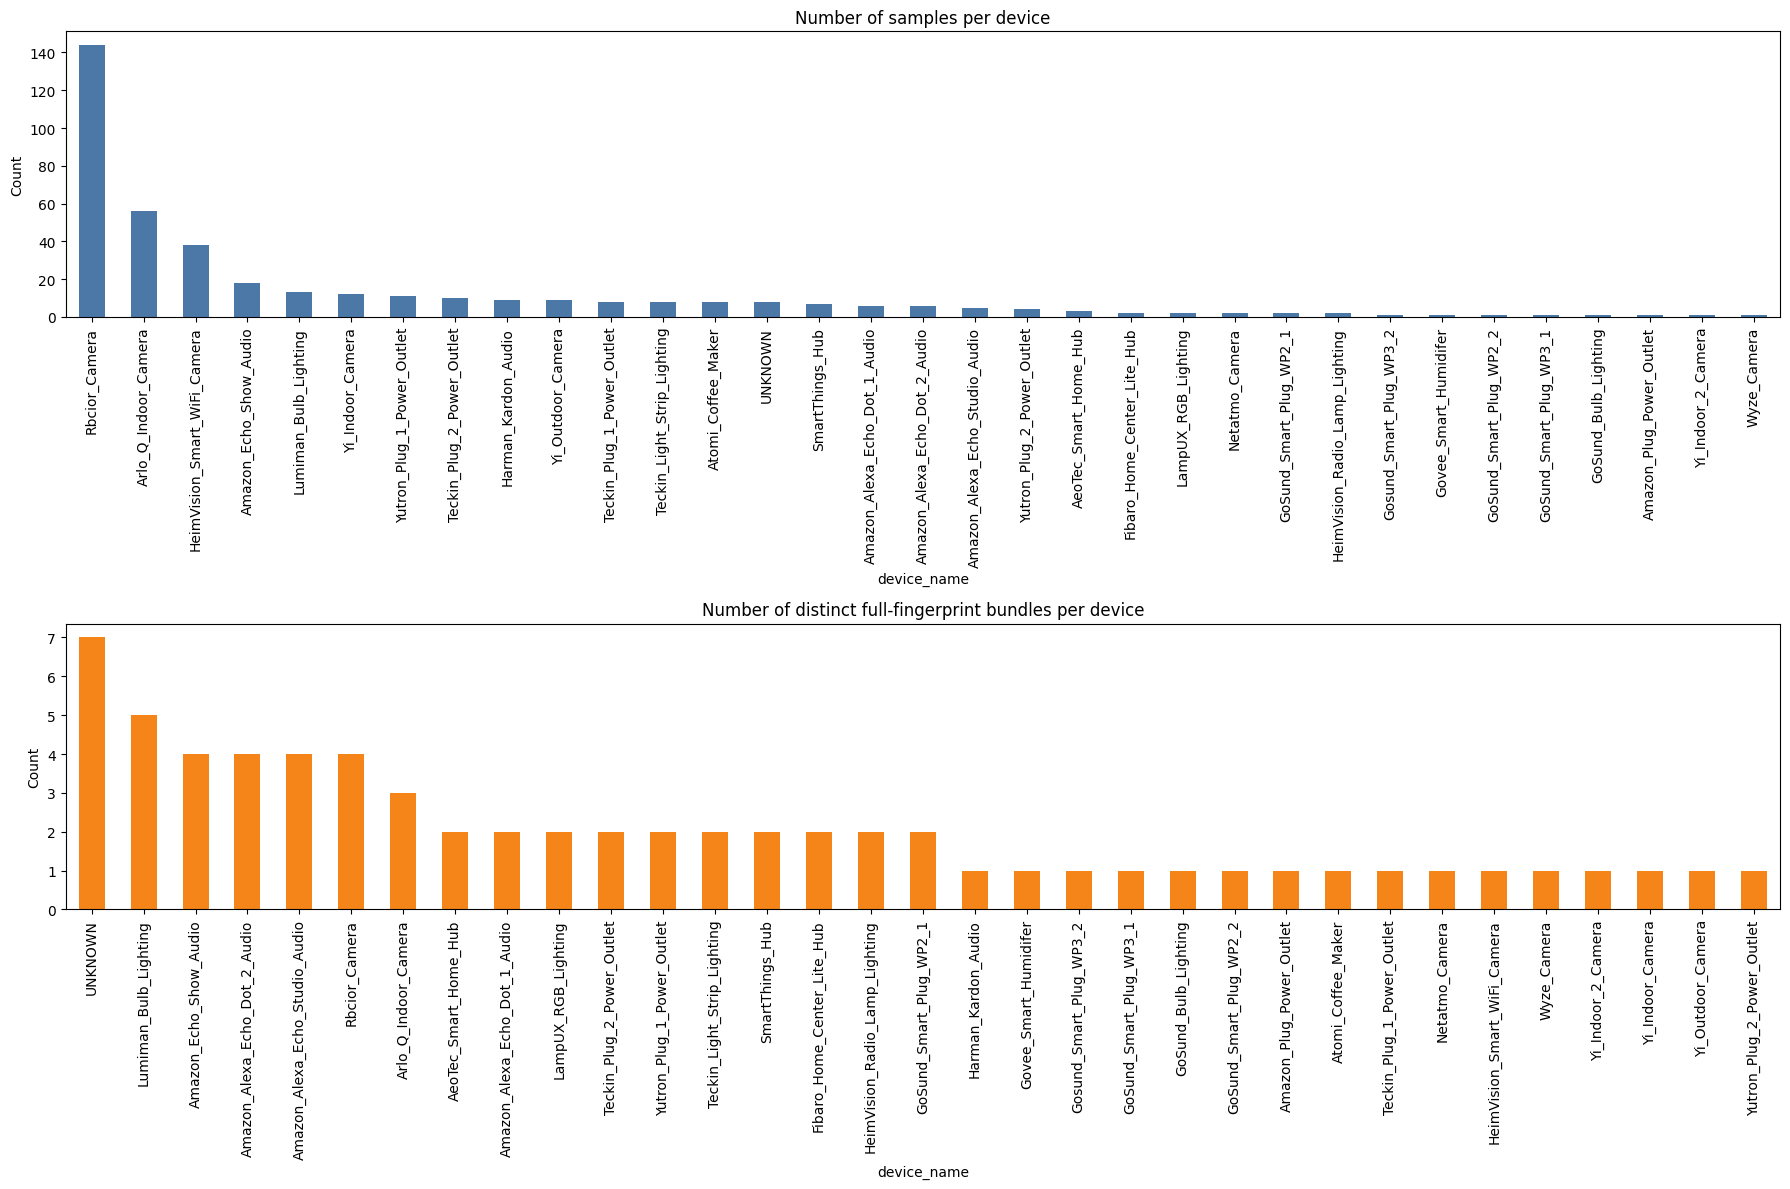

In [2]:
import matplotlib.pyplot as plt

# Build one joined fingerprint bundle per row to count unique patterns by device.

df["signature_bundle"] = (
    df[signature_columns]
    .fillna("")
    .astype(str)
    .agg(" | ".join, axis=1)
)

total_samples = df.groupby("device_name").size().sort_values(ascending=False)
distinct_signatures = df.groupby("device_name")["signature_bundle"].nunique().sort_values(ascending=False)

print("Number of samples per device_name")
print(total_samples.to_string())
print()
print("Number of distinct full-fingerprint bundles per device_name")
print(distinct_signatures.to_string())

# Plot the number of records and distinct full-fingerprint bundles per device.
fig, axes = plt.subplots(2, 1, figsize=(18, 12))

total_samples.plot(kind="bar", ax=axes[0], color="#4C78A8")
axes[0].set_title("Number of samples per device")
axes[0].set_xlabel("device_name")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=90)

distinct_signatures.plot(kind="bar", ax=axes[1], color="#F58518")
axes[1].set_title("Number of distinct full-fingerprint bundles per device")
axes[1].set_xlabel("device_name")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

## Device Filtering And Balancing

This section removes devices with too few records for reliable splitting and caps the largest classes to reduce class imbalance before modeling.


In [3]:
# Filter out devices with too few samples and cap very large classes for balance.
min_samples_per_device = 3
max_samples_per_device = 60

device_counts = df["device_name"].value_counts()
valid_devices = device_counts[device_counts >= min_samples_per_device].index

# Keep only devices that satisfy the minimum support threshold.
df = df[df["device_name"].isin(valid_devices)].copy()

# Optionally limit the number of samples per device to reduce class imbalance.
if max_samples_per_device is not None:
    df = (
        df.groupby("device_name", group_keys=False)
        .head(max_samples_per_device)
        .reset_index(drop=True)
    )
else:
    df = df.reset_index(drop=True)

filtered_counts = df["device_name"].value_counts().sort_values(ascending=False)

print("Number of records per device_name after filtering")
print(filtered_counts.to_string())
print()
print(f"Minimum threshold applied: {min_samples_per_device}")
print(f"Maximum threshold applied: {max_samples_per_device}")
print(f"Number of devices kept: {len(filtered_counts)}")
print(f"Total number of records after filtering: {len(df)}")

df.head()

Number of records per device_name after filtering
device_name
Rbcior_Camera                     60
Arlo_Q_Indoor_Camera              56
HeimVision_Smart_WiFi_Camera      38
Amazon_Echo_Show_Audio            18
Lumiman_Bulb_Lighting             13
Yi_Indoor_Camera                  12
Yutron_Plug_1_Power_Outlet        11
Teckin_Plug_2_Power_Outlet        10
Harman_Kardon_Audio                9
Yi_Outdoor_Camera                  9
Atomi_Coffee_Maker                 8
Teckin_Light_Strip_Lighting        8
UNKNOWN                            8
Teckin_Plug_1_Power_Outlet         8
SmartThings_Hub                    7
Amazon_Alexa_Echo_Dot_2_Audio      6
Amazon_Alexa_Echo_Dot_1_Audio      6
Amazon_Alexa_Echo_Studio_Audio     5
Yutron_Plug_2_Power_Outlet         4
AeoTec_Smart_Home_Hub              3

Minimum threshold applied: 3
Maximum threshold applied: 60
Number of devices kept: 20
Total number of records after filtering: 299


,device_name,ja4,ja4s,ja4t,ja4ts,signature_bundle
0,Rbcior_Camera,t12d040600_39def8a70f78_9b994c9d23f8,t120300_c027_7815a3cc5eb2,14600_2-4-8-1-3_1460_3,65535_2-4-8-1-3_1460_9,t12d040600_39def8a70f78_9b994c9d23f8 | t120300...
1,Rbcior_Camera,t12d040600_39def8a70f78_9b994c9d23f8,t120400_c013_d23d0754cf28,14600_2-4-8-1-3_1460_3,14600_2-3-1-4-1-1_1432_8,t12d040600_39def8a70f78_9b994c9d23f8 | t120400...
2,Yutron_Plug_1_Power_Outlet,t12i020600_96495e174321_c9df22c671e6,t120300_00ae_468c819633e6,2920_2_1460_0,65535_2_1460_0,t12i020600_96495e174321_c9df22c671e6 | t120300...
3,Rbcior_Camera,t12d040600_39def8a70f78_9b994c9d23f8,t120400_c013_d23d0754cf28,14600_2-4-8-1-3_1460_3,14600_2-3-1-4-1-1_1432_8,t12d040600_39def8a70f78_9b994c9d23f8 | t120400...
4,Rbcior_Camera,t12d040600_39def8a70f78_9b994c9d23f8,t120400_c013_d23d0754cf28,14600_2-4-8-1-3_1460_3,14600_2-3-1-4-1-1_1432_8,t12d040600_39def8a70f78_9b994c9d23f8 | t120400...


## Per-Device 70/10/20 Split

Samples are split independently for each device into train, validation, and test subsets. The validation subset is used only to choose the best dictionary strategy.


In [4]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

target_column = "device_name"
feature_columns = signature_columns

# Keep only the selected fingerprints and the target device label.
df_model = df[feature_columns + [target_column]].copy()

# Normalize feature and target values before splitting.
for column in feature_columns + [target_column]:
    df_model[column] = (
        df_model[column]
        .fillna("unknown")
        .astype(str)
        .str.strip()
        .str.lower()
    )

# Remove classes that are too small to support a train/validation/test split.
class_counts_after_cleaning = df_model[target_column].value_counts()
valid_classes_for_split = class_counts_after_cleaning[class_counts_after_cleaning >= 3].index
removed_classes = sorted(set(class_counts_after_cleaning.index) - set(valid_classes_for_split))

if removed_classes:
    print(
        "Classes removed because they have fewer than 3 valid samples after cleaning:",
        removed_classes,
    )
    df_model = df_model[df_model[target_column].isin(valid_classes_for_split)].reset_index(drop=True)

X = df_model[feature_columns].copy()
y = df_model[target_column].copy()

X_train_list, X_val_list, X_test_list = [], [], []
y_train_list, y_val_list, y_test_list = [], [], []

# Split each device independently to preserve all classes across the three splits.
for device in df_model[target_column].unique():
    device_mask = df_model[target_column] == device
    X_device = X[device_mask].reset_index(drop=True)
    y_device = y[device_mask].reset_index(drop=True)

    X_temp, X_test_device, y_temp, y_test_device = train_test_split(
        X_device,
        y_device,
        test_size=0.2,
        random_state=42,
        shuffle=True,
    )

    train_ratio = 0.70 / 0.80
    X_train_device, X_val_device, y_train_device, y_val_device = train_test_split(
        X_temp,
        y_temp,
        train_size=train_ratio,
        random_state=42,
        shuffle=True,
    )

    X_train_list.append(X_train_device)
    X_val_list.append(X_val_device)
    X_test_list.append(X_test_device)
    y_train_list.append(y_train_device)
    y_val_list.append(y_val_device)
    y_test_list.append(y_test_device)

X_train = pd.concat(X_train_list, ignore_index=True)
X_val = pd.concat(X_val_list, ignore_index=True)
X_test = pd.concat(X_test_list, ignore_index=True)
y_train_raw = pd.concat(y_train_list, ignore_index=True)
y_val_raw = pd.concat(y_val_list, ignore_index=True)
y_test_raw = pd.concat(y_test_list, ignore_index=True)

# Encode device names as numeric labels for scikit-learn metrics.
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_val = label_encoder.transform(y_val_raw)
y_test = label_encoder.transform(y_test_raw)
class_names = label_encoder.classes_

print("Per-device split: 70% train, 10% validation, 20% test")
print(f"Valid records after cleaning: {len(df_model)}")
print(f"Target classes: {len(class_names)}")
print(f"Train size: {len(X_train)}")
print(f"Validation size: {len(X_val)}")
print(f"Test size: {len(X_test)}")
print("First classes:", class_names[:10])

Per-device split: 70% train, 10% validation, 20% test
Valid records after cleaning: 299
Target classes: 20
Train size: 192
Validation size: 39
Test size: 68
First classes: ['aeotec_smart_home_hub' 'amazon_alexa_echo_dot_1_audio'
 'amazon_alexa_echo_dot_2_audio' 'amazon_alexa_echo_studio_audio'
 'amazon_echo_show_audio' 'arlo_q_indoor_camera' 'atomi_coffee_maker'
 'harman_kardon_audio' 'heimvision_smart_wifi_camera'
 'lumiman_bulb_lighting']


## Split Class Balance

This section checks the normalized class distribution in the train, validation, and test splits to confirm that the per-device split kept the classes represented.


In [5]:
# Inspect class balance in each split after per-device sampling.
print("Class distribution in y_train_raw:")
print(y_train_raw.value_counts(normalize=True).sort_index())
print()

print("Class distribution in y_val_raw:")
print(y_val_raw.value_counts(normalize=True).sort_index())
print()

print("Class distribution in y_test_raw:")
print(y_test_raw.value_counts(normalize=True).sort_index())

Class distribution in y_train_raw:
device_name
aeotec_smart_home_hub             0.005208
amazon_alexa_echo_dot_1_audio     0.015625
amazon_alexa_echo_dot_2_audio     0.015625
amazon_alexa_echo_studio_audio    0.015625
amazon_echo_show_audio            0.062500
arlo_q_indoor_camera              0.197917
atomi_coffee_maker                0.026042
harman_kardon_audio               0.031250
heimvision_smart_wifi_camera      0.135417
lumiman_bulb_lighting             0.041667
rbcior_camera                     0.213542
smartthings_hub                   0.020833
teckin_light_strip_lighting       0.026042
teckin_plug_1_power_outlet        0.026042
teckin_plug_2_power_outlet        0.031250
unknown                           0.026042
yi_indoor_camera                  0.036458
yi_outdoor_camera                 0.031250
yutron_plug_1_power_outlet        0.031250
yutron_plug_2_power_outlet        0.010417
Name: proportion, dtype: float64

Class distribution in y_val_raw:
device_name
aeotec_smart_h

## Dictionary Model And Strategy Selection

This section builds a dictionary classifier from the training data. It first tries exact full-fingerprint matches, then optional partial votes from individual fingerprint values, and finally a fallback strategy. Several strategies are compared on the validation split.


In [6]:
from collections import Counter, defaultdict
from sklearn.metrics import accuracy_score, f1_score

# Convert a row into its complete fingerprint representation.
def row_to_bundle(row, columns):
    return tuple(row[col] for col in columns)

# Build the lookup tables used by the dictionary classifier.
# The model stores full fingerprint bundles, single-feature evidence, and the global class prior.
def build_dictionary_model(X_train_df, y_train_series, columns):
    bundle_to_counter = defaultdict(Counter)
    single_column_to_counter = {
        col: defaultdict(Counter) for col in columns
    }
    label_counter = Counter(y_train_series)

    for idx, row in X_train_df.iterrows():
        label = y_train_series.iloc[idx]
        bundle = row_to_bundle(row, columns)

        # Count how many times each full fingerprint appears for each device.
        bundle_to_counter[bundle][label] += 1

        # Count how informative each individual fingerprint value is for each device.
        for col in columns:
            single_value = row[col]
            single_column_to_counter[col][single_value][label] += 1

    return {
        "bundle_to_counter": bundle_to_counter,
        "single_column_to_counter": single_column_to_counter,
        "global_label_counter": label_counter,
    }

# Predict labels using exact fingerprint matches first, then partial evidence, then a fallback.
def predict_with_dictionary(model, X_df, columns, fallback_strategy, use_partial_vote, min_bundle_support):
    predictions = []
    seen_exact = 0
    used_partial = 0
    used_global = 0

    for _, row in X_df.iterrows():
        bundle = row_to_bundle(row, columns)
        bundle_counter = model["bundle_to_counter"].get(bundle, Counter())

        # Use the exact full fingerprint only if it has enough support in training.
        if sum(bundle_counter.values()) >= min_bundle_support and bundle_counter:
            predictions.append(bundle_counter.most_common(1)[0][0])
            seen_exact += 1
            continue

        partial_counter = Counter()
        if use_partial_vote:
            # Aggregate votes from matching individual fingerprint values.
            for col in columns:
                value = row[col]
                partial_counter.update(model["single_column_to_counter"][col].get(value, Counter()))

        if partial_counter:
            predictions.append(partial_counter.most_common(1)[0][0])
            used_partial += 1
            continue

        # Use either the global majority class or the closest known bundle as a fallback.
        if fallback_strategy == "global_majority":
            predictions.append(model["global_label_counter"].most_common(1)[0][0])
        else:
            shared_counter = Counter()
            for known_bundle, known_labels in model["bundle_to_counter"].items():
                overlap = sum(1 for a, b in zip(bundle, known_bundle) if a == b)
                if overlap > 0:
                    shared_counter.update({label: count * overlap for label, count in known_labels.items()})

            if shared_counter:
                predictions.append(shared_counter.most_common(1)[0][0])
            else:
                predictions.append(model["global_label_counter"].most_common(1)[0][0])

        used_global += 1

    # Track how often each prediction path was used.
    stats = {
        "exact_match_rate": seen_exact / len(X_df) if len(X_df) else 0.0,
        "partial_vote_rate": used_partial / len(X_df) if len(X_df) else 0.0,
        "global_fallback_rate": used_global / len(X_df) if len(X_df) else 0.0,
    }
    return predictions, stats

# Compare a small grid of dictionary strategies on the validation split.
strategy_grid = [
    {"fallback_strategy": "global_majority", "use_partial_vote": False, "min_bundle_support": 1},
    {"fallback_strategy": "global_majority", "use_partial_vote": True, "min_bundle_support": 1},
    {"fallback_strategy": "global_majority", "use_partial_vote": True, "min_bundle_support": 2},
    {"fallback_strategy": "overlap_weighted", "use_partial_vote": False, "min_bundle_support": 1},
    {"fallback_strategy": "overlap_weighted", "use_partial_vote": True, "min_bundle_support": 1},
    {"fallback_strategy": "overlap_weighted", "use_partial_vote": True, "min_bundle_support": 2},
]

# Build the dictionary only with the training split.
dictionary_model = build_dictionary_model(X_train, y_train_raw, feature_columns)

search_rows = []
best_strategy = None
best_val_f1 = -1.0
best_val_accuracy = -1.0

# Evaluate each strategy on validation and keep the best one.
for strategy in strategy_grid:
    val_predictions_raw, val_stats = predict_with_dictionary(
        dictionary_model,
        X_val,
        feature_columns,
        fallback_strategy=strategy["fallback_strategy"],
        use_partial_vote=strategy["use_partial_vote"],
        min_bundle_support=strategy["min_bundle_support"],
    )

    # Convert raw predicted labels into the encoded label space used for metrics.
    val_predictions = label_encoder.transform(pd.Series(val_predictions_raw))
    val_accuracy = accuracy_score(y_val, val_predictions)
    val_macro_f1 = f1_score(y_val, val_predictions, average="macro", zero_division=0)

    search_rows.append({
        **strategy,
        **val_stats,
        "val_accuracy": float(val_accuracy),
        "val_macro_f1": float(val_macro_f1),
    })

    # Select the best strategy by macro F1, breaking ties with accuracy.
    if (val_macro_f1 > best_val_f1) or (val_macro_f1 == best_val_f1 and val_accuracy > best_val_accuracy):
        best_val_f1 = val_macro_f1
        best_val_accuracy = val_accuracy
        best_strategy = strategy

# Rank all evaluated strategies from best to worst.
search_results_df = pd.DataFrame(search_rows).sort_values(
    ["val_macro_f1", "val_accuracy", "exact_match_rate"],
    ascending=False,
).reset_index(drop=True)

print("Strategies evaluated on the validation split:")
display(search_results_df)
print()
print("Best strategy found:")
print(best_strategy)
print(f"Best validation macro F1: {best_val_f1:.4f}")
print(f"Associated validation accuracy: {best_val_accuracy:.4f}")

Strategies evaluated on the validation split:


,fallback_strategy,use_partial_vote,min_bundle_support,exact_match_rate,partial_vote_rate,global_fallback_rate,val_accuracy,val_macro_f1
0,global_majority,True,1,0.897436,0.102564,0.000000,0.794872,0.592222
1,overlap_weighted,False,1,0.897436,0.000000,0.102564,0.794872,0.592222
2,overlap_weighted,True,1,0.897436,0.102564,0.000000,0.794872,0.592222
3,global_majority,True,2,0.871795,0.128205,0.000000,0.769231,0.539306
4,overlap_weighted,True,2,0.871795,0.128205,0.000000,0.769231,0.539306
5,global_majority,False,1,0.897436,0.000000,0.102564,0.717949,0.467778



Best strategy found:
{'fallback_strategy': 'global_majority', 'use_partial_vote': True, 'min_bundle_support': 1}
Best validation macro F1: 0.5922
Associated validation accuracy: 0.7949


## Final Training And Test Evaluation

After selecting the best validation strategy, the dictionary is rebuilt with train and validation data together. The final model is evaluated on the held-out test split using accuracy, macro metrics, top-k accuracy, prediction-path usage, and prediction time.


In [7]:
import time
from sklearn.metrics import classification_report, precision_score, recall_score, top_k_accuracy_score

# Merge training and validation data after selecting the best strategy.
train_val_X = pd.concat([X_train, X_val], ignore_index=True)
train_val_y_raw = pd.concat([y_train_raw, y_val_raw], ignore_index=True)
train_val_y = label_encoder.transform(train_val_y_raw)

# Rebuild the dictionary with all non-test data before final evaluation.
final_dictionary_model = build_dictionary_model(train_val_X, train_val_y_raw, feature_columns)

# Measure prediction time on train+validation and test splits.
train_val_start = time.perf_counter()
train_val_predictions_raw, train_val_stats = predict_with_dictionary(
    final_dictionary_model,
    train_val_X,
    feature_columns,
    fallback_strategy=best_strategy["fallback_strategy"],
    use_partial_vote=best_strategy["use_partial_vote"],
    min_bundle_support=best_strategy["min_bundle_support"],
)
train_val_elapsed = time.perf_counter() - train_val_start

test_start = time.perf_counter()
test_predictions_raw, test_stats = predict_with_dictionary(
    final_dictionary_model,
    X_test,
    feature_columns,
    fallback_strategy=best_strategy["fallback_strategy"],
    use_partial_vote=best_strategy["use_partial_vote"],
    min_bundle_support=best_strategy["min_bundle_support"],
)
test_elapsed = time.perf_counter() - test_start

train_val_predictions = label_encoder.transform(pd.Series(train_val_predictions_raw))
test_predictions = label_encoder.transform(pd.Series(test_predictions_raw))

train_val_accuracy = accuracy_score(train_val_y, train_val_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)

train_val_f1_macro = f1_score(train_val_y, train_val_predictions, average="macro", zero_division=0)
test_f1_macro = f1_score(y_test, test_predictions, average="macro", zero_division=0)

macro_precision = precision_score(y_test, test_predictions, average="macro", zero_division=0)
macro_recall = recall_score(y_test, test_predictions, average="macro", zero_division=0)

# Create deterministic one-hot scores so top-k metrics can be computed.
test_label_scores = []
for raw_label in test_predictions_raw:
    score_row = np.zeros(len(class_names), dtype=float)
    predicted_idx = label_encoder.transform([raw_label])[0]
    score_row[predicted_idx] = 1.0
    test_label_scores.append(score_row)

test_label_scores = np.vstack(test_label_scores) if test_label_scores else np.zeros((0, len(class_names)))

top_3_k = min(3, len(class_names))
top_5_k = min(5, len(class_names))

if len(class_names) <= top_3_k:
    test_top_3_accuracy = 1.0
else:
    test_top_3_accuracy = top_k_accuracy_score(
        y_test,
        test_label_scores,
        k=top_3_k,
        labels=np.arange(len(class_names)),
    )

if len(class_names) <= top_5_k:
    test_top_5_accuracy = 1.0
else:
    test_top_5_accuracy = top_k_accuracy_score(
        y_test,
        test_label_scores,
        k=top_5_k,
        labels=np.arange(len(class_names)),
    )

# Report the average latency per test prediction in milliseconds.
average_prediction_time_ms = (test_elapsed / len(X_test) * 1000) if len(X_test) else 0.0

print("=" * 80)
print("GENERAL RESULTS")
print("=" * 80)
print(f"Final strategy: {best_strategy}")
print()
print("Accuracy:")
print(f"  - Train+Val: {train_val_accuracy:.4f}")
print(f"  - Test:      {test_accuracy:.4f}")
print()
print("Macro F1 Score:")
print(f"  - Best validation: {best_val_f1:.4f}")
print(f"  - Train+Val:        {train_val_f1_macro:.4f}")
print(f"  - Test:             {test_f1_macro:.4f}")
print()
print("Top-k accuracy on the test split:")
print(f"  - top_1_accuracy: {test_accuracy:.4f}")
print(f"  - top_{top_3_k}_accuracy: {test_top_3_accuracy:.4f}")
print(f"  - top_{top_5_k}_accuracy: {test_top_5_accuracy:.4f}")
print()
print("Strategy usage on the test split:")
print(f"  - exact_match_rate:      {test_stats['exact_match_rate']:.4f}")
print(f"  - partial_vote_rate:     {test_stats['partial_vote_rate']:.4f}")
print(f"  - global_fallback_rate:  {test_stats['global_fallback_rate']:.4f}")
print()
print(f"Average prediction time: {average_prediction_time_ms:.3f} ms")
print()
print("=" * 80)
print("CLASSIFICATION REPORT - TEST")
print("=" * 80)
print(
    classification_report(
        y_test,
        test_predictions,
        labels=np.arange(len(class_names)),
        target_names=class_names,
        zero_division=0,
    )
)

GENERAL RESULTS
Final strategy: {'fallback_strategy': 'global_majority', 'use_partial_vote': True, 'min_bundle_support': 1}

Accuracy:
  - Train+Val: 0.8571
  - Test:      0.8235

Macro F1 Score:
  - Best validation: 0.5922
  - Train+Val:        0.6408
  - Test:             0.5914

Top-k accuracy on the test split:
  - top_1_accuracy: 0.8235
  - top_3_accuracy: 0.8382
  - top_5_accuracy: 0.8676

Strategy usage on the test split:
  - exact_match_rate:      0.9118
  - partial_vote_rate:     0.0882
  - global_fallback_rate:  0.0000

Average prediction time: 0.144 ms

CLASSIFICATION REPORT - TEST
                                precision    recall  f1-score   support

         aeotec_smart_home_hub       0.00      0.00      0.00         1
 amazon_alexa_echo_dot_1_audio       1.00      1.00      1.00         2
 amazon_alexa_echo_dot_2_audio       1.00      1.00      1.00         2
amazon_alexa_echo_studio_audio       0.00      0.00      0.00         1
        amazon_echo_show_audio       1.

## Metrics Visualization

This section plots the final test metrics, top-k accuracy, and dictionary usage breakdown, then prints a compact summary of the final results.


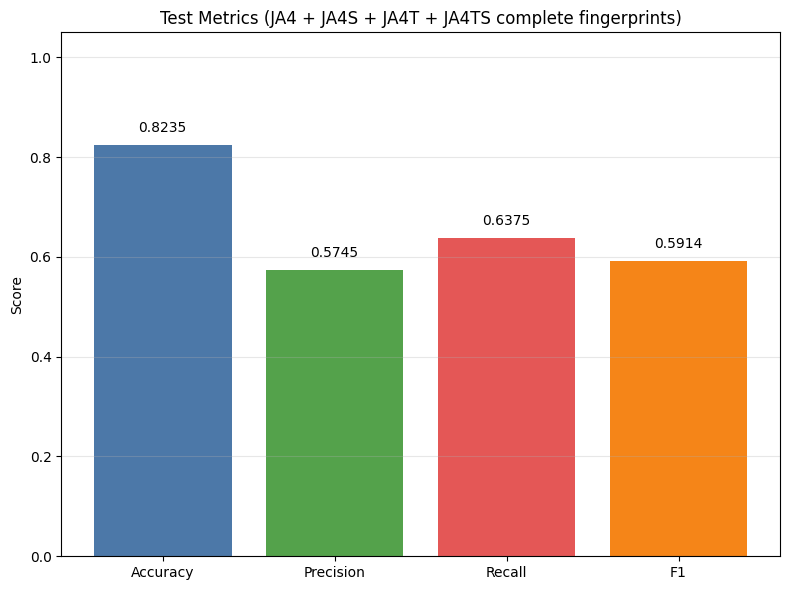

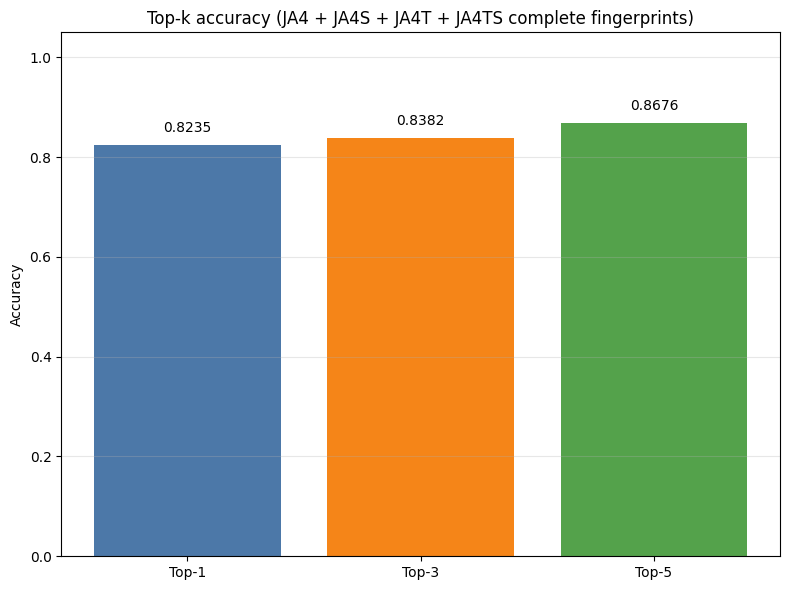

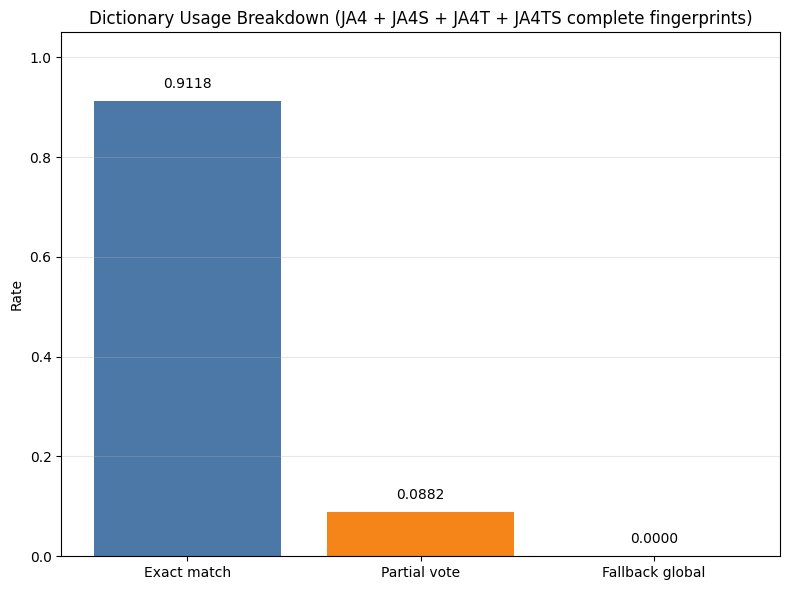

FINAL METRICS SUMMARY
- validation_macro_f1_for_tuning: 0.5922
- test_accuracy: 0.8235
- test_macro_precision: 0.5745
- test_macro_recall: 0.6375
- test_macro_f1: 0.5914
- top_1_accuracy: 0.8235
- top_3_accuracy: 0.8382
- top_5_accuracy: 0.8676
- test_exact_match_rate: 0.9118
- test_partial_vote_rate: 0.0882
- test_global_fallback_rate: 0.0000
- avg_prediction_time_ms: 0.1435

Best strategy used in the final model:
  - fallback_strategy: global_majority
  - use_partial_vote: True
  - min_bundle_support: 1


In [8]:
import matplotlib.pyplot as plt

# Name the fingerprint set used in the charts and final summary.
feature_set_label = "JA4 + JA4S + JA4T + JA4TS complete fingerprints"

metrics = ["Accuracy", "Precision", "Recall", "F1"]
values = [test_accuracy, macro_precision, macro_recall, test_f1_macro]

# Prepare top-k and prediction-path usage summaries.
top_k_labels = ["Top-1", "Top-3", "Top-5"]
top_k_values = [test_accuracy, test_top_3_accuracy, test_top_5_accuracy]

usage_labels = ["Exact match", "Partial vote", "Fallback global"]
usage_values = [
    test_stats["exact_match_rate"],
    test_stats["partial_vote_rate"],
    test_stats["global_fallback_rate"],
]

# Plot the main classification metrics on the test split.
plt.figure(figsize=(8, 6))
bars = plt.bar(metrics, values, color=["#4C78A8", "#54A24B", "#E45756", "#F58518"])
plt.title(f"Test Metrics ({feature_set_label})")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.02, f"{yval:.4f}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

# Plot top-k accuracy on the test split.
plt.figure(figsize=(8, 6))
bars = plt.bar(top_k_labels, top_k_values, color=["#4C78A8", "#F58518", "#54A24B"])
plt.title(f"Top-k accuracy ({feature_set_label})")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.02, f"{yval:.4f}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

# Plot how often each dictionary prediction path is used.
plt.figure(figsize=(8, 6))
bars = plt.bar(usage_labels, usage_values, color=["#4C78A8", "#F58518", "#54A24B"])
plt.title(f"Dictionary Usage Breakdown ({feature_set_label})")
plt.ylabel("Rate")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.02, f"{yval:.4f}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

# Store the final metrics in a compact dictionary for reporting.
metrics_summary = {
    "validation_macro_f1_for_tuning": float(best_val_f1),
    "test_accuracy": float(test_accuracy),
    "test_macro_precision": float(macro_precision),
    "test_macro_recall": float(macro_recall),
    "test_macro_f1": float(test_f1_macro),
    "top_1_accuracy": float(test_accuracy),
    f"top_{top_3_k}_accuracy": float(test_top_3_accuracy),
    f"top_{top_5_k}_accuracy": float(test_top_5_accuracy),
    "test_exact_match_rate": float(test_stats["exact_match_rate"]),
    "test_partial_vote_rate": float(test_stats["partial_vote_rate"]),
    "test_global_fallback_rate": float(test_stats["global_fallback_rate"]),
    "avg_prediction_time_ms": float(average_prediction_time_ms),
}

print("=" * 80)
print("FINAL METRICS SUMMARY")
print("=" * 80)
for metric_name, metric_value in metrics_summary.items():
    print(f"- {metric_name}: {metric_value:.4f}")

print()
print("Best strategy used in the final model:")
for param, value in best_strategy.items():
    print(f"  - {param}: {value}")